n_examples=10  sent=(10, 5196)  received=(10, 5196)
mod=qpsk  dc_offset_A=0.122


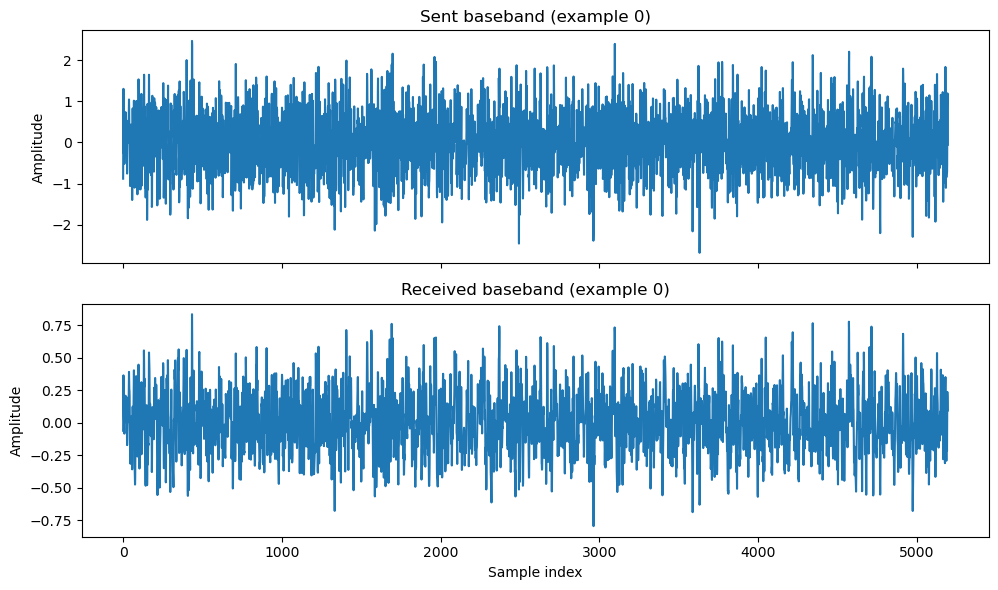

In [1]:
import zarr
import numpy as np
import matplotlib.pyplot as plt

def load_and_plot_first(dataset_path):
    g = zarr.open_group(dataset_path, mode="r")
    sent = np.asarray(g["sent_baseband"])
    received = np.asarray(g["received_baseband"])
    print(f"n_examples={sent.shape[0]}  sent={sent.shape}  received={received.shape}")
    print(f"mod={g.attrs.get('modulation_format')}  dc_offset_A={g.attrs.get('dc_offset_A')}")

    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax[0].plot(sent[0]);     ax[0].set_title("Sent baseband (example 0)");     ax[0].set_ylabel("Amplitude")
    ax[1].plot(received[0]); ax[1].set_title("Received baseband (example 0)"); ax[1].set_ylabel("Amplitude")
    ax[1].set_xlabel("Sample index")
    plt.tight_layout()
    plt.show()
    return sent, received

sent, received = load_and_plot_first("/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/sweeps/dc0.122A_fmin300000_fmax1.299e+07_20260615_1430.zarr")


In [19]:
from modules.models import TCN_channel

# Toy model for calculating receptive field

tcn = TCN_channel(nlayers=4, dilation_base=2, kernel_size=8, hidden_channels=32)
print(f"Receptive field of TCN: {tcn.receptive_field}")

Receptive field of TCN: 106


In [1]:
import zarr
import numpy as np

zarr_path = "/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/sweeps/dc0.052A_fmin300000_fmax7.6e+06_20260630_1743.zarr"
n_samples = 3

root = zarr.open_group(zarr_path, mode="r")

print("=== attributes ===")
for k, v in root.attrs.items():
    print(f"  {k}: {v}")

print("\n=== arrays ===")
for name in root.array_keys():
    data = root[name][:]
    print(f"\n[{name}]  shape={data.shape}  dtype={data.dtype}")
    print(f"  min={data.min():.4g}  max={data.max():.4g}  mean={data.mean():.4g}")
    for i in range(min(n_samples, len(data))):
        row = data[i]
        print(f"  [{i}]: {np.array2string(row[:8], precision=4, suppress_small=True)}" +
              (" ..." if len(row) > 8 else ""))


=== attributes ===
  dc_offset_A: 0.052
  f_min_hz: 300000.0
  f_max_hz: 7600000.0
  active_carrier_indices: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75]
  cyclic_prefix_length: 76
  preamble_length: 256
  modulation_format: m7_apsk_constellation

=== arrays ===

[source_bits]  shape=(5000, 146)  dtype=uint8
  min=0  max=1  mean=0.5003
  [0]: [0 0 1 0 0 0 1 0] ...
  [1]: [1 0 1 0 0 1 1 0] ...
  [2]: [1 1 0 0 1 1 0 1] ...

[sent_burst]  shape=(5000, 940)  dtype=float32
  min=-3  max=3  mean=-8.677e-05
  [0]: [-0.     -0.1977  0.1788  0.9435  1.7197  2.1439  2.053   1.5582] ...
  [1]: [-0.     -0.1977  0.1788  0.9435  1.7197  2.1439  2.053   1.5582] ...
  [2]: [-0.     -0.1977  0.1788  0.9435  1.7197  2.1439  2.053   1.5582] ...

[received_burst]  sha

In [10]:
from pathlib import Path
from dataclasses import dataclass, field
import numpy as np
import zarr

ZARR_PATH = "/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/sweeps/dc0.052A_fmin300000_fmax7.6e+06_20260630_1743.zarr"

@dataclass
class OFDMSettings:
    # stored in zarr attrs
    dc_offset_A: float; f_min_hz: float; f_max_hz: float
    active_carrier_indices: np.ndarray
    cyclic_prefix_length: int; preamble_length: int; modulation_format: str
    # derived
    subcarrier_spacing_hz: float = None
    num_carriers: int = None
    subcarrier_freqs_hz: np.ndarray = None
    burst_length: int = None
    baseband_fft_length: int = None
    symbol_length_with_cp: int = None
    baseband_sampling_rate_hz: float = None
    upsample_factor: int = None
    num_leading_zero_subcarriers: int = None
    bits_per_symbol: int = None
    num_samples: int = None

def load_ofdm_dataset(zarr_path):
    g = zarr.open_group(str(zarr_path), mode="r")
    a = dict(g.attrs)
    active   = np.asarray(a["active_carrier_indices"], dtype=int)
    f_min    = float(a["f_min_hz"])
    cp       = int(a["cyclic_prefix_length"])
    preamble = int(a["preamble_length"])

    arrays = {n: g[n] for n in ("sent_burst", "received_burst", "source_bits", "decoded_bits")}
    num_samples, burst_length = arrays["sent_burst"].shape
    bits_per_row = arrays["source_bits"].shape[1]

    # subcarrier k -> k*spacing, first active carrier sits at f_min  =>  spacing = f_min / active[0]
    spacing = f_min / int(active[0])
    # burst = preamble + (fft + cp), all baseband
    fft_len = burst_length - preamble - cp
    fs      = fft_len * spacing
    n_carriers    = len(active)
    leading_zeros = int(active[0]) - 1                 # bins between DC and f_min (DC excluded)
    denom   = 2 * (n_carriers + leading_zeros + 1)     # fft_len = upsample * denom
    upsample = fft_len // denom if fft_len % denom == 0 else fft_len / denom

    s = OFDMSettings(
        dc_offset_A=float(a["dc_offset_A"]), f_min_hz=f_min, f_max_hz=float(a["f_max_hz"]),
        active_carrier_indices=active, cyclic_prefix_length=cp, preamble_length=preamble,
        modulation_format=str(a["modulation_format"]),
        subcarrier_spacing_hz=spacing, num_carriers=n_carriers,
        subcarrier_freqs_hz=active * spacing, burst_length=int(burst_length),
        baseband_fft_length=int(fft_len), symbol_length_with_cp=int(fft_len + cp),
        baseband_sampling_rate_hz=fs, upsample_factor=upsample,
        num_leading_zero_subcarriers=leading_zeros,
        bits_per_symbol=int(round(bits_per_row / n_carriers)), num_samples=int(num_samples),
    )
    return s, arrays

settings, arrays = load_ofdm_dataset(ZARR_PATH)
for k, v in vars(settings).items():
    if isinstance(v, np.ndarray):
        v = f"[{len(v)} vals] {v[:3].tolist()}...{v[-3:].tolist()}"
    print(f"{k:<28} = {v}")

# optional: rebuild the exact constellation object the experiment used
# import sys; sys.path.insert(0, "/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED")
# from modules.constellation_diagram import get_constellation
# constellation = get_constellation(settings.modulation_format)


dc_offset_A                  = 0.052
f_min_hz                     = 300000.0
f_max_hz                     = 7600000.0
active_carrier_indices       = [73 vals] [3, 4, 5]...[73, 74, 75]
cyclic_prefix_length         = 76
preamble_length              = 256
modulation_format            = m7_apsk_constellation
subcarrier_spacing_hz        = 100000.0
num_carriers                 = 73
subcarrier_freqs_hz          = [73 vals] [300000.0, 400000.0, 500000.0]...[7300000.0, 7400000.0, 7500000.0]
burst_length                 = 940
baseband_fft_length          = 608
symbol_length_with_cp        = 684
baseband_sampling_rate_hz    = 60800000.0
upsample_factor              = 4
num_leading_zero_subcarriers = 2
bits_per_symbol              = 2
num_samples                  = 5000


In [17]:
np.arange(3, 76) * 1.125

array([ 3.375,  4.5  ,  5.625,  6.75 ,  7.875,  9.   , 10.125, 11.25 ,
       12.375, 13.5  , 14.625, 15.75 , 16.875, 18.   , 19.125, 20.25 ,
       21.375, 22.5  , 23.625, 24.75 , 25.875, 27.   , 28.125, 29.25 ,
       30.375, 31.5  , 32.625, 33.75 , 34.875, 36.   , 37.125, 38.25 ,
       39.375, 40.5  , 41.625, 42.75 , 43.875, 45.   , 46.125, 47.25 ,
       48.375, 49.5  , 50.625, 51.75 , 52.875, 54.   , 55.125, 56.25 ,
       57.375, 58.5  , 59.625, 60.75 , 61.875, 63.   , 64.125, 65.25 ,
       66.375, 67.5  , 68.625, 69.75 , 70.875, 72.   , 73.125, 74.25 ,
       75.375, 76.5  , 77.625, 78.75 , 79.875, 81.   , 82.125, 83.25 ,
       84.375])

In [16]:
import torch
x = torch.arange(3, 76)*1.125
x.round().long()

tensor([ 3,  4,  6,  7,  8,  9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22,
        24, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 40, 42, 43,
        44, 45, 46, 47, 48, 50, 51, 52, 53, 54, 55, 56, 57, 58, 60, 61, 62, 63,
        64, 65, 66, 68, 69, 70, 71, 72, 73, 74, 75, 76, 78, 79, 80, 81, 82, 83,
        84])

In [3]:
import numpy as np, zarr

g = zarr.open_group("/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/sweeps/dc0.052A_fmin300000_fmax7.6e+06_20260630_1743.zarr", mode="r")
a = dict(g.attrs)
active = np.asarray(a["active_carrier_indices"], int)
cp, pre = int(a["cyclic_prefix_length"]), int(a["preamble_length"])
sent, recv = g["sent_burst"], g["received_burst"]
N = sent.shape[1] - pre - cp                      # 608

def carrier_syms(burst_rows, delta=0):
    w = burst_rows[:, pre+cp+delta : pre+cp+delta+N]
    return np.fft.fft(w, norm="ortho", axis=1)[:, active]

X = carrier_syms(sent[:])
Y = carrier_syms(recv[:])
H = (Y / X).mean(0)                                # averaged channel per carrier
phase = np.unwrap(np.angle(H))
slope = np.polyfit(active, phase, 1)[0]            # rad per carrier index
delta_samples = slope * N / (2*np.pi)
print(f"channel timing offset  ≈ {delta_samples:+.3f} samples  (slope {slope:+.4f} rad/carrier)")


channel timing offset  ≈ +1.293 samples  (slope +0.0134 rad/carrier)


In [8]:
import numpy as np, zarr

# ---- point these at the two datasets you're comparing ----
COLLECTION = "/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/sweeps/dc0.052A_fmin300000_fmax7.6e+06_20260630_1743.zarr"
VAL_MODEL  = "/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/experiments/train_and_validate/solar_storm_ed_validation_20260702_0127/validation.zarr/tcn_ae_830cebe2_9b00089d"

# ---- OFDM geometry comes from the collection zarr attrs (same experiment) ----
g = zarr.open_group(COLLECTION, mode="r")
a = dict(g.attrs)
active = np.asarray(a["active_carrier_indices"], int)
cp, pre = int(a["cyclic_prefix_length"]), int(a["preamble_length"])
sent_burst, recv_burst = g["sent_burst"][:], g["received_burst"][:]
N = sent_burst.shape[1] - pre - cp                       # 608

def phase_slope(Y, X):
    """Return (delta_samples, slope_rad_per_carrier) of the linear phase ramp of <Y/X>."""
    H = (Y / X).mean(0)
    slope = np.polyfit(active, np.unwrap(np.angle(H)), 1)[0]
    return slope * N / (2*np.pi), slope

def syms_from_bursts(rows, delta=0):
    """FFT the post-CP window (offset by delta) of full [preamble|CP|symbol] rows."""
    w = rows[:, pre+cp+delta : pre+cp+delta+N]
    return np.fft.fft(w, norm="ortho", axis=1)[:, active]

def syms_from_symbols(rows):
    """validation.zarr rows are already the N-length symbol (CP/preamble stripped)."""
    return np.fft.fft(rows, norm="ortho", axis=1)[:, active]

# ===== Test A: timing offset in each environment =====
Xc = syms_from_bursts(sent_burst)
d_chan, s_chan = phase_slope(syms_from_bursts(recv_burst), Xc)

vg = zarr.open_group(VAL_MODEL, mode="r")
Xv, Yv = syms_from_symbols(vg["sent_time"][:]), syms_from_symbols(vg["received_time"][:])
d_val, s_val = phase_slope(Yv, Xv)

print(f"COLLECTION (channel, no eq): delta = {d_chan:+.3f} samp   slope {s_chan:+.4f} rad/carrier")
print(f"VALIDATION residual (post-decoder, {vg.attrs.get('channel_form','?')}): "
      f"delta = {d_val:+.3f} samp   slope {s_val:+.4f} rad/carrier")
print(f"--> environment mismatch: {d_val - d_chan:+.3f} samples\n")

# ===== Test B: window-offset sweep on collection data (AWG loops -> tile to emulate) =====
loop = np.concatenate([recv_burst, recv_burst], axis=1)   # burst is periodic in the AWG table
Href = (syms_from_bursts(recv_burst) / Xc).mean(0)         # 1-tap equalizer fit at delta=0
print("delta  EVM%   (early=CP-protected, late=next-preamble leakage)")
best = (1e9, 0)
for d in range(-30, 31, 2):
    Yk = np.fft.fft(loop[:, pre+cp+d:pre+cp+d+N], norm="ortho", axis=1)[:, active]
    evm = np.sqrt(np.mean(np.abs(Yk/Href - Xc)**2) / np.mean(np.abs(Xc)**2)) * 100
    best = min(best, (evm, d))
    bar = "#" * int(min(evm, 60))
    print(f"{d:+4d}  {evm:6.2f}  {bar}")
print(f"\nEVM-optimal window offset: delta* = {best[1]:+d} samples (EVM {best[0]:.2f}%)")


COLLECTION (channel, no eq): delta = +1.293 samp   slope +0.0134 rad/carrier
VALIDATION residual (post-decoder, nonprob TCN): delta = +0.006 samp   slope +0.0001 rad/carrier
--> environment mismatch: -1.286 samples

delta  EVM%   (early=CP-protected, late=next-preamble leakage)
 -30  152.65  ############################################################
 -28  149.39  ############################################################
 -26  146.61  ############################################################
 -24  150.42  ############################################################
 -22  153.74  ############################################################
 -20  149.44  ############################################################
 -18  145.21  ############################################################
 -16  150.59  ############################################################
 -14  155.99  ############################################################
 -12  149.38  ################################

COLLECTION channel (no eq)       delta= +1.293 samp | de-ramped residual RMS =  6.72 deg
VALIDATION residual (post-E/D)   delta= +0.006 samp | de-ramped residual RMS =  6.01 deg


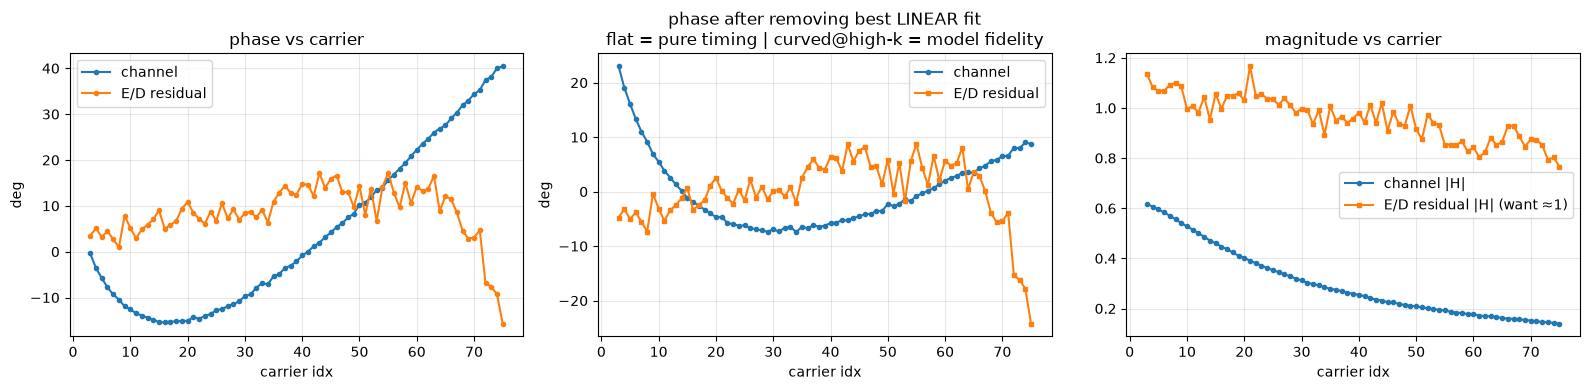

In [9]:
import numpy as np, zarr
import matplotlib.pyplot as plt

COLLECTION = "/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/sweeps/dc0.052A_fmin300000_fmax7.6e+06_20260630_1743.zarr"
VAL_MODEL  = "/home/photonicslab/Desktop/microled_project/prob_tcn_for_LED/data/experiments/train_and_validate/solar_storm_ed_validation_20260702_0127/validation.zarr/tcn_ae_830cebe2_9b00089d"

g = zarr.open_group(COLLECTION, mode="r"); a = dict(g.attrs)
active = np.asarray(a["active_carrier_indices"], int)
cp, pre = int(a["cyclic_prefix_length"]), int(a["preamble_length"])
sent_burst, recv_burst = g["sent_burst"][:], g["received_burst"][:]
N = sent_burst.shape[1] - pre - cp

def car(rows, stripped=False):
    w = rows if stripped else rows[:, pre+cp:pre+cp+N]      # validation rows are already the N-sample symbol
    return np.fft.fft(w, norm="ortho", axis=1)[:, active]

Xc, Yc = car(sent_burst), car(recv_burst)
vg = zarr.open_group(VAL_MODEL, mode="r")
Xv, Yv = car(vg["sent_time"][:], stripped=True), car(vg["received_time"][:], stripped=True)

def analyze(Y, X, label):
    H  = (Y / X).mean(0)
    ph = np.unwrap(np.angle(H))
    slope, intercept = np.polyfit(active, ph, 1)         # best-fit linear = pure-timing component
    resid = ph - (slope*active + intercept)              # what's left is NOT timing
    delta = slope * N / (2*np.pi)
    print(f"{label:32s} delta={delta:+7.3f} samp | de-ramped residual RMS = "
          f"{np.degrees(np.sqrt(np.mean(resid**2))):5.2f} deg")
    return H, ph, resid

Hc, phc, rc = analyze(Yc, Xc, "COLLECTION channel (no eq)")
Hv, phv, rv = analyze(Yv, Xv, "VALIDATION residual (post-E/D)")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for k, y, lab in [(active, np.degrees(phc), "channel"), (active, np.degrees(phv), "E/D residual")]:
    ax[0].plot(k, y, "o-", ms=3, label=lab)
ax[0].set(title="phase vs carrier", xlabel="carrier idx", ylabel="deg"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(active, np.degrees(rc), "o-", ms=3, label="channel")
ax[1].plot(active, np.degrees(rv), "s-", ms=3, label="E/D residual")
ax[1].set(title="phase after removing best LINEAR fit\nflat = pure timing | curved@high-k = model fidelity",
          xlabel="carrier idx", ylabel="deg"); ax[1].legend(); ax[1].grid(alpha=.3)

ax[2].plot(active, np.abs(Hc), "o-", ms=3, label="channel |H|")
ax[2].plot(active, np.abs(Hv), "s-", ms=3, label="E/D residual |H| (want ≈1)")
ax[2].set(title="magnitude vs carrier", xlabel="carrier idx"); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()
